In [1]:
import numpy as np
import pandas as pd
import pickle
import os
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import numpy as np 
from collections import Counter
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import SelectKBest, mutual_info_classif

In [2]:
def map_videos_to_labels():
    # Mapping emotions to binary classification: 0 for Negative, 1 for Positive
    emotion_map = {
        1: 0, 2: 0, 3: 0,  # Anger (Negative)
        4: 0, 5: 0, 6: 0,  # Disgust (Negative)
        7: 0, 8: 0, 9: 0,  # Fear (Negative)
        10: 0, 11: 0, 12: 0,  # Sadness (Negative)
        17: 1, 18: 1, 19: 1,  # Amusement (Positive)
        20: 1, 21: 1, 22: 1,  # Inspiration (Positive)
        23: 1, 24: 1, 25: 1,  # Joy (Positive)
        26: 1, 27: 1, 28: 1,  # Tenderness (Positive)
    }
    return emotion_map


In [3]:
def create_emotions_from_map():
    emotion_map = map_videos_to_labels()  # Get the emotion mapping
    emotions = []  # List will contain only 'Positive' or 'Negative'

    # Create emotion names based on the mapping (Positive or Negative)
    for key, value in emotion_map.items():
        if value == 0:
            emotions.append('Negative')
        elif value == 1:
            emotions.append('Positive')

    return emotions


In [4]:
def load_features(data_path):
    """
    Load DE and PSD features for all subjects, and map them to labels per second.
    """
    all_data = []  # Store data for all subjects
    emotion_map = map_videos_to_labels()  # Get the mapping of video IDs to emotions

    for subject in range(123):
        # File paths
        de_file = os.path.join(data_path, 'DE', f'sub{subject:03d}.pkl.pkl')
        psd_file = os.path.join(data_path, 'PSD', f'sub{subject:03d}.pkl.pkl')

        # Check file existence
        if not os.path.exists(de_file) or not os.path.exists(psd_file):
            print(f"File missing for subject {subject}: {de_file} or {psd_file}")
            continue

        # Load DE and PSD features
        try:
            with open(de_file, 'rb') as f:
                de_features = pickle.load(f)
            with open(psd_file, 'rb') as f:
                psd_features = pickle.load(f)
        except Exception as e:
            print(f"Error loading files for subject {subject}: {e}")
            continue

        # Ensure DE and PSD features are correctly arranged as 4D arrays
        de_data_4d = np.expand_dims(de_features, axis=0) if de_features.ndim <= 3 else de_features
        psd_data_4d = np.expand_dims(psd_features, axis=0) if psd_features.ndim <= 3 else psd_features

        # Retrieve dimensions
        video_num, elec_num, trial_dur, freq_band = de_data_4d.shape
        
        # Combined results will have shape (VideoNum * TrialDur, 321)
        result_2d = np.zeros(((video_num-4) * trial_dur, 321))

        for v in range(video_num):
            if v in [12, 13, 14, 15]:
                continue
            for t in range(trial_dur):
                # Flatten the DE and PSD features into a single array
                de_flattened_values = de_data_4d[v, :, t, :].flatten()     # Shape: (160,)
                psd_flattened_values = psd_data_4d[v, :, t, :].flatten()   # Shape: (160,)
                
                # Combine DE and PSD features
                combined_values = np.concatenate((de_flattened_values, psd_flattened_values))

                # Get the emotion label for the current VideoNum (index + 1)
                emotion_label = emotion_map.get(v + 1, -1)

                # Fill the result array
                if(v>15):
                    result_2d[(v-4) * trial_dur + t, :320] = combined_values  # First 320 columns
                    result_2d[(v-4) * trial_dur + t, 320] = int(emotion_label)  # Last column for the label
                else:
                    result_2d[v * trial_dur + t, :320] = combined_values  # First 320 columns
                    result_2d[v * trial_dur + t, 320] = int(emotion_label)  # Last column for the label

        # Append this subject's 2D data to all_data
        all_data.append(result_2d)

    # Combine all subjects' data into a single 2D array
    if all_data:
        final_data = np.vstack(all_data)
    else:
        final_data = np.array([])  # Handle the case if no data was loaded
    
    print(final_data.shape)
    return final_data

# Example usage:
# data_path = 'path_to_your_data_directory'
# features_and_labels = load_features(data_path)

In [10]:
def evaluate_classifiers(X_train, X_test, y_train, y_test, emotions):
    """
    Compare multiple classifiers.
    """
    classifiers = {
        # 'Support Vector Machine': SVC(kernel='rbf'),
        # 'Random Forest': RandomForestClassifier(n_estimators=500),
        # 'Neural Network': MLPClassifier(max_iter=1000),
        'K-Nearest Neighbors': KNeighborsClassifier(),
        # 'Decision Tree': DecisionTreeClassifier()
    }

    results = {}

    for name, clf in classifiers.items():
        # Train and evaluate
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        # Store results
        results[name] = {
            'classification_report': classification_report(y_test, y_pred, target_names = emotions),
            'confusion_matrix': confusion_matrix(y_test, y_pred)
        }

    # print(results)
    return results

In [6]:
def run_study(data_path):
    # Load features
    X = load_features(data_path)
    y = X[:, -1]

    # Class distribution
    class_counts = Counter(y)
    print("Class distribution:", class_counts)

    # Feature scaling
    scaler = StandardScaler()
    X_combined = X[:, :-1]
    X_combined = scaler.fit_transform(X_combined)

    # Prepare data
    X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.15, random_state=42)

    emotions = [
        'Positive','Negative'
    ]
    # print("Emotion categories:", emotions)

    # 7. Evaluate classifiers
    results = evaluate_classifiers(X_train, X_test, y_train, y_test, emotions)

    return results


(88560, 321)
Class distribution: Counter({np.float64(0.0): 44280, np.float64(1.0): 44280})

K-Nearest Neighbors Results:
              precision    recall  f1-score   support

    Positive       0.71      0.71      0.71      6618
    Negative       0.72      0.72      0.72      6666

    accuracy                           0.72     13284
   macro avg       0.72      0.72      0.72     13284
weighted avg       0.72      0.72      0.72     13284



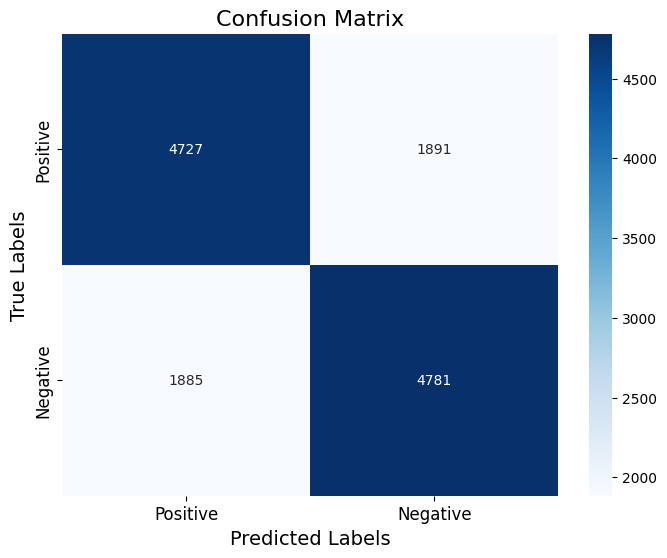

In [ ]:
# 6. Example usage to test the run_study function
if __name__ == '__main__':
    study_results = run_study('')  # Replace with your actual data path

    # Print results for each classifier
    for clf_name, clf_results in study_results.items():
        print(f"\n{clf_name} Results:")
        print(clf_results['classification_report'])
        plot_confusion_matrix(clf_results['confusion_matrix'],['Positive','Negative'])



K-Nearest Neighbors Results:
              precision    recall  f1-score   support

    Positive       0.71      0.71      0.71      6618
    Negative       0.72      0.72      0.72      6666

    accuracy                           0.72     13284
   macro avg       0.72      0.72      0.72     13284
weighted avg       0.72      0.72      0.72     13284



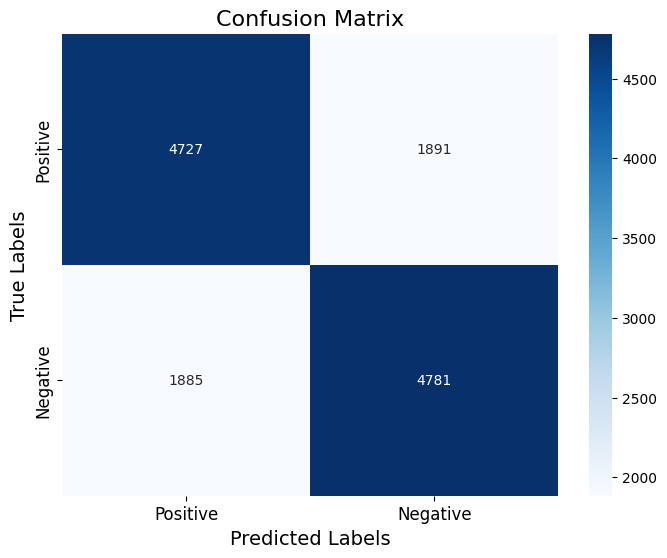

In [17]:
for clf_name, clf_results in study_results.items():
        print(f"\n{clf_name} Results:")
        print(clf_results['classification_report'])
        plot_confusion_matrix(clf_results['confusion_matrix'],['Positive','Negative'])

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(confusion_matrix, class_names, title="Confusion Matrix", cmap="Blues"):
    """
    Plots a labeled and colorful confusion matrix using Seaborn heatmap.

    Parameters:
    confusion_matrix (array-like): Confusion matrix to be visualized.
    class_names (list): List of class names for the matrix.
    title (str): Title for the plot.
    cmap (str): Colormap for the heatmap.
    """
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap=cmap, xticklabels=class_names, yticklabels=class_names)
    plt.title(title, fontsize=16)
    plt.xlabel("Predicted Labels", fontsize=14)
    plt.ylabel("True Labels", fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.show()